In [ ]:
# Installations

!pip install scikit-learn
!pip install pandas

In [ ]:
# Imports

from sklearn import datasets
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Question 1 partie 1 : Chargement

iris = datasets.load_iris()
X = iris.data
y = iris.target

In [4]:
# Question 1 partie 2 : Dimensions

print("Dimensions de X :", X.shape)
print("Taille de y :", y.shape)

feature_names = iris.feature_names
target_names = iris.target_names
print("Descripteurs :", feature_names)
print("Nombre de descripteurs :", len(feature_names))
print("Classes :", target_names)
print("Nombre de classes :", len(target_names))

Dimensions de X : (150, 4)
Taille de y : (150,)
Descripteurs : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Nombre de descripteurs : 4
Classes : ['setosa' 'versicolor' 'virginica']
Nombre de classes : 3


In [5]:
# Question 2 : Moyenne et variance

moyennes = np.mean(X, axis=0)
variances = np.var(X, axis=0)

stats_df = pd.DataFrame({
    'Descripteur': iris.feature_names,
    'Moyenne': moyennes,
    'Variance': variances,
    'Écart-type': np.sqrt(variances)
})

print(stats_df.round(3))

         Descripteur  Moyenne  Variance  Écart-type
0  sepal length (cm)    5.843     0.681       0.825
1   sepal width (cm)    3.057     0.189       0.434
2  petal length (cm)    3.758     3.096       1.759
3   petal width (cm)    1.199     0.577       0.760


In [6]:
# Question 3 partie 1 : moyennes et variances conditionnelles (intra-classe)

n_classes = 3
n_descripteurs = 4

moyennes_cond = np.zeros((n_classes, n_descripteurs))
variances_cond = np.zeros((n_classes, n_descripteurs))

for classe in range(n_classes):
    X_classe = X[y == classe]
    
    moyennes_cond[classe] = np.mean(X_classe, axis=0)
    variances_cond[classe] = np.var(X_classe, axis=0, ddof=1)

print("--- MOYENNES CONDITIONNELLES ---\n")
moyennes_df = pd.DataFrame(
    moyennes_cond,
    columns=iris.feature_names,
    index=[f'{iris.target_names[i]} (classe {i})' for i in range(3)]
)
print(moyennes_df.round(3))

print("\n--- VARIANCES INTRA-CLASSE (conditionnelles) ---\n")
variances_df = pd.DataFrame(
    variances_cond,
    columns=iris.feature_names,
    index=[f'{iris.target_names[i]} (classe {i})' for i in range(3)]
)
print(variances_df.round(3))

variance_intra = np.mean(variances_cond, axis=0)
print("\n--- VARIANCE INTRA-CLASSE MOYENNE ---")
print(pd.Series(variance_intra, index=iris.feature_names).round(3))

--- MOYENNES CONDITIONNELLES ---

                       sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa (classe 0)                  5.006             3.428              1.462   
versicolor (classe 1)              5.936             2.770              4.260   
virginica (classe 2)               6.588             2.974              5.552   

                       petal width (cm)  
setosa (classe 0)                 0.246  
versicolor (classe 1)             1.326  
virginica (classe 2)              2.026  

--- VARIANCES INTRA-CLASSE (conditionnelles) ---

                       sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa (classe 0)                  0.124             0.144              0.030   
versicolor (classe 1)              0.266             0.098              0.221   
virginica (classe 2)               0.404             0.104              0.305   

                       petal width (cm)  
setosa (classe 0)                 0.011  
versicolor (c

In [39]:
# Question 3 partie 2 : variances interclasses

variance_totale = np.var(X, axis=0)
variance_inter = variance_totale - variance_intra

print("\n--- VARIANCE INTER-CLASSE ---")
print(pd.Series(variance_inter, index=iris.feature_names).round(3))


--- VARIANCE INTER-CLASSE ---
sepal length (cm)    0.416
sepal width (cm)     0.073
petal length (cm)    2.910
petal width (cm)     0.535
dtype: float64


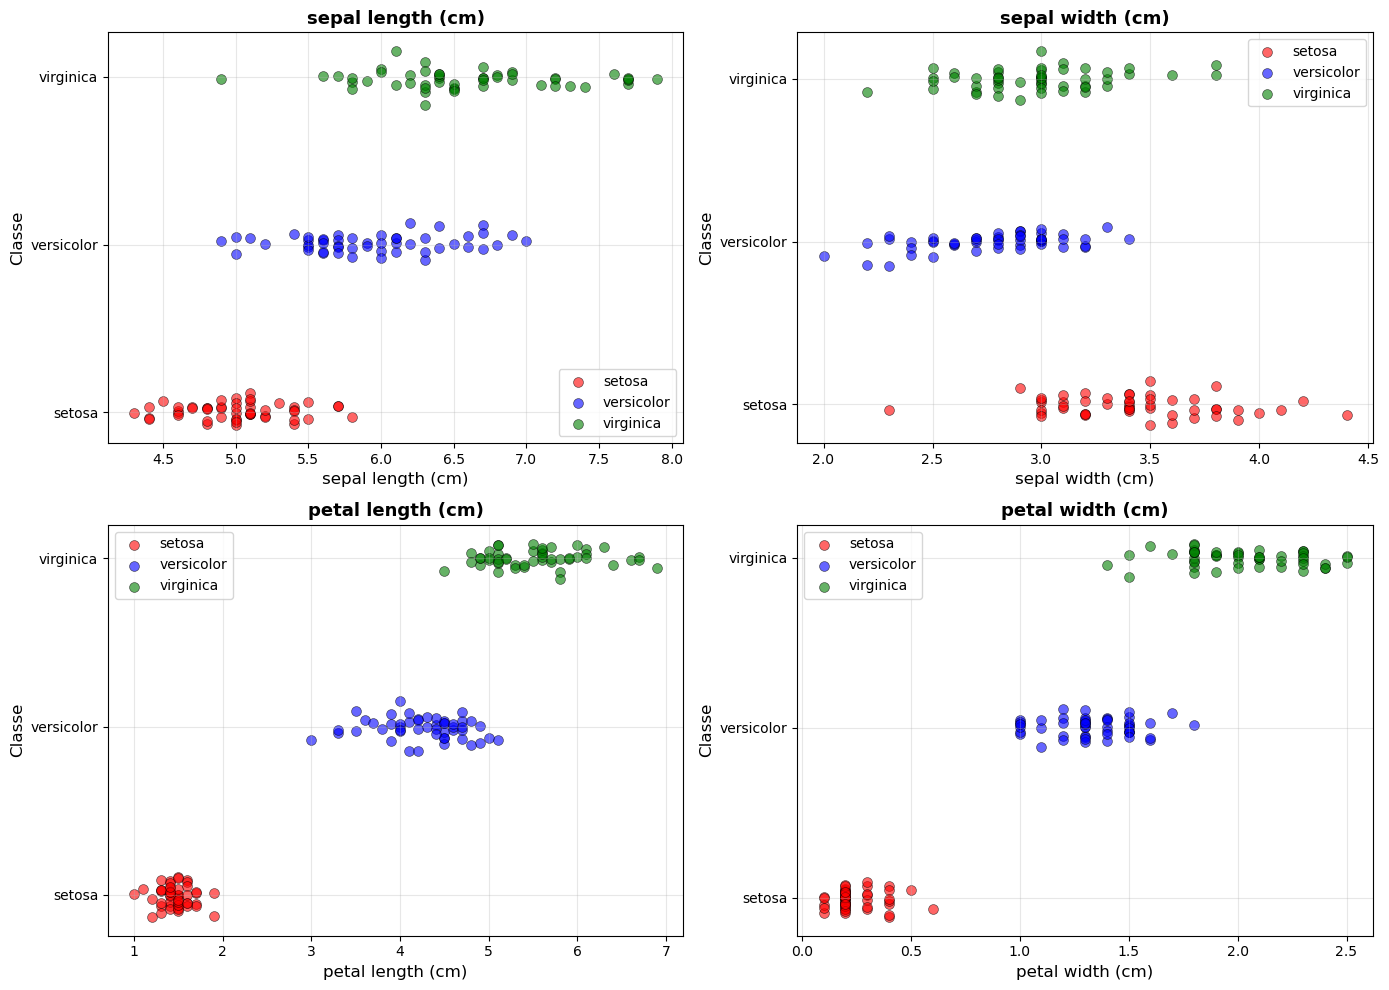

In [8]:
# Question 3 partie 3 : visualisation

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

colors = ['red', 'blue', 'green']
class_names = iris.target_names

for i in range(4):
    ax = axes[i]
    
    for classe in range(3):
        indices = y == classe
        X_classe = X[indices, i]
        y_classe = y[indices]
        
        y_jitter = y_classe + np.random.normal(0, 0.05, size=len(y_classe))
        
        ax.scatter(X_classe, y_jitter, alpha=0.6, 
                  color=colors[classe], label=class_names[classe],
                  s=50, edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel(iris.feature_names[i], fontsize=12)
    ax.set_ylabel('Classe', fontsize=12)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(class_names)
    ax.set_title(f'{iris.feature_names[i]}', fontsize=13, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
plt.savefig("graphe1.png")
plt.tight_layout()
plt.show()

In [42]:
# Question 3 partie 4 : pour commenter

print("\n--- POUVOIR DISCRIMINANT (Var_inter / Var_totale) ---")
ratio_discriminant = variance_inter / variance_totale
discriminant_df = pd.DataFrame({
    'Descripteur': iris.feature_names,
    'Var inter': variance_inter,
    'Var totale': variance_totale,
    'Ratio (%)': ratio_discriminant * 100
})
print(discriminant_df.round(3))


--- POUVOIR DISCRIMINANT (Var_inter / Var_totale) ---
         Descripteur  Var inter  Var totale  Ratio (%)
0  sepal length (cm)      0.416       0.681     61.092
1   sepal width (cm)      0.073       0.189     38.855
2  petal length (cm)      2.910       3.096     94.018
3   petal width (cm)      0.535       0.577     92.743


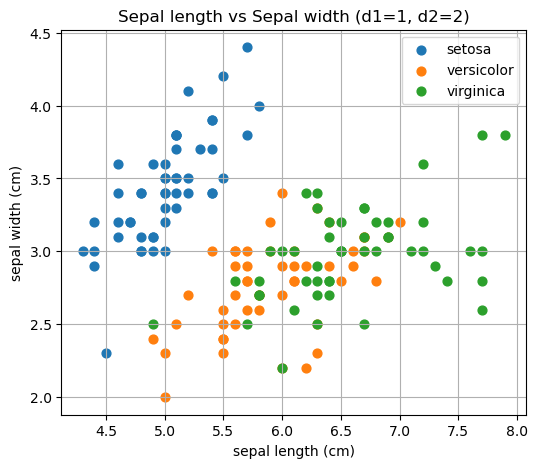

In [10]:
# Question 4 partie 1 : affichage des données dans le plan (d1, d2)

d1, d2 = 0, 1
X_2d = X[:, [d1, d2]]

plt.figure(figsize=(6,5))
for i, name in enumerate(target_names):
    plt.scatter(X_2d[y==i, 0], X_2d[y==i, 1], label=name, s=40)
plt.xlabel(iris.feature_names[d1])
plt.ylabel(iris.feature_names[d2])
plt.title("Sepal length vs Sepal width (d1=1, d2=2)")
plt.legend()
plt.grid(True)

plt.savefig("graphe2.png")
plt.show()

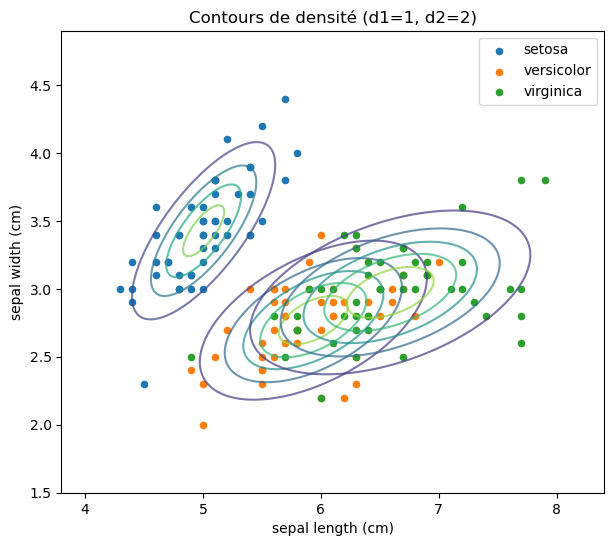

In [11]:
# Question 4 partie 2 : densité de probabilité conditionnelles

gmm_models = []
for i in range(3):
    gmm = GaussianMixture(n_components=1, covariance_type='full', random_state=0)
    gmm.fit(X_2d[y==i])
    gmm_models.append(gmm)

# Visualisation des densités
xx, yy = np.meshgrid(
    np.linspace(X_2d[:,0].min()-0.5, X_2d[:,0].max()+0.5, 200),
    np.linspace(X_2d[:,1].min()-0.5, X_2d[:,1].max()+0.5, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]

plt.figure(figsize=(7,6))
for i, name in enumerate(target_names):
    plt.scatter(X_2d[y==i, 0], X_2d[y==i, 1], label=name, s=20)
    zz = np.exp(gmm_models[i].score_samples(grid))
    zz = zz.reshape(xx.shape)
    plt.contour(xx, yy, zz, levels=5, alpha=0.7)
plt.xlabel(iris.feature_names[d1])
plt.ylabel(iris.feature_names[d2])
plt.title("Contours de densité (d1=1, d2=2)")
plt.legend()

plt.savefig("graphe3.png")
plt.show()

In [47]:
# Question 4 partie 3 :

# 4.3 Matrices de covariance conditionnelles
for i, name in enumerate(target_names):
    print(f"\nClasse : {name}")
    print(gmm_models[i].covariances_[0])



Classe : setosa
[[0.121765 0.097232]
 [0.097232 0.140817]]

Classe : versicolor
[[0.261105 0.08348 ]
 [0.08348  0.096501]]

Classe : virginica
[[0.396257 0.091888]
 [0.091888 0.101925]]


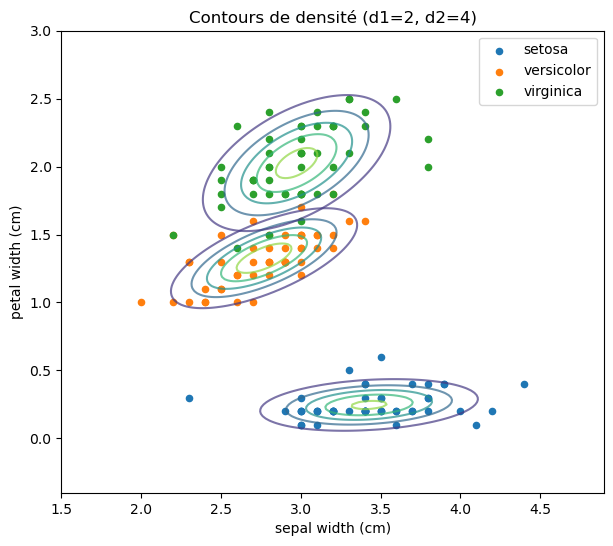


Classe : setosa
[[0.140817 0.009112]
 [0.009112 0.010885]]

Classe : versicolor
[[0.096501 0.04038 ]
 [0.04038  0.038325]]

Classe : virginica
[[0.101925 0.046676]
 [0.046676 0.073925]]


In [12]:
# Question 4 partie 4 :

d1, d2 = 1, 3
X_2d = X[:, [d1, d2]]

gmm_models = []
for i in range(3):
    gmm = GaussianMixture(n_components=1, covariance_type='full', random_state=0)
    gmm.fit(X_2d[y==i])
    gmm_models.append(gmm)

xx, yy = np.meshgrid(
    np.linspace(X_2d[:,0].min()-0.5, X_2d[:,0].max()+0.5, 200),
    np.linspace(X_2d[:,1].min()-0.5, X_2d[:,1].max()+0.5, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]

plt.figure(figsize=(7,6))
for i, name in enumerate(target_names):
    plt.scatter(X_2d[y==i, 0], X_2d[y==i, 1], label=name, s=20)
    zz = np.exp(gmm_models[i].score_samples(grid))
    zz = zz.reshape(xx.shape)
    plt.contour(xx, yy, zz, levels=5, alpha=0.7)
plt.xlabel(iris.feature_names[d1])
plt.ylabel(iris.feature_names[d2])
plt.title("Contours de densité (d1=2, d2=4)")
plt.legend()

plt.savefig("graphe4.png")
plt.show()

# Covariances
for i, name in enumerate(target_names):
    print(f"\nClasse : {name}")
    print(gmm_models[i].covariances_[0])

In [ ]:
# Question 4 partie 5 :



In [55]:
# Question 4 partie 6 :

def evaluate_knn(d1, d2):
    X_sel = X[:, [d1, d2]]
    X_train, X_test, y_train, y_test = train_test_split(
        X_sel, y, test_size=0.2, random_state=1
    )
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Paire ({iris.feature_names[d1]}, {iris.feature_names[d2]}) → Accuracy = {acc:.3f}")

# Évaluation sur les deux paires
evaluate_knn(0, 1)
evaluate_knn(1, 3)  

Paire (sepal length (cm), sepal width (cm)) → Accuracy = 0.733
Paire (sepal width (cm), petal width (cm)) → Accuracy = 0.967
